### Data loading and Understanding

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
df = pd.read_csv("../data/raw/cardekho.csv")

In [29]:
df.head(10)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248.0,74,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498.0,103.52,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497.0,78,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396.0,90,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298.0,88.2,5.0
5,Hyundai Xcent 1.2 VTVT E Plus,2017,440000,45000,Petrol,Individual,Manual,First Owner,20.14,1197.0,81.86,5.0
6,Maruti Wagon R LXI DUO BSIII,2007,96000,175000,LPG,Individual,Manual,First Owner,17.30,1061.0,57.5,5.0
7,Maruti 800 DX BSII,2001,45000,5000,Petrol,Individual,Manual,Second Owner,16.10,796.0,37,4.0
8,Toyota Etios VXD,2011,350000,90000,Diesel,Individual,Manual,First Owner,23.59,1364.0,67.1,5.0
9,Ford Figo Diesel Celebration Edition,2013,200000,169000,Diesel,Individual,Manual,First Owner,20.00,1399.0,68.1,5.0


In [30]:
df.shape

(8128, 12)

In [31]:
df.dtypes

name                   object
year                    int64
selling_price           int64
km_driven               int64
fuel                   object
seller_type            object
transmission           object
owner                  object
mileage(km/ltr/kg)    float64
engine                float64
max_power              object
seats                 float64
dtype: object

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                8128 non-null   object 
 1   year                8128 non-null   int64  
 2   selling_price       8128 non-null   int64  
 3   km_driven           8128 non-null   int64  
 4   fuel                8128 non-null   object 
 5   seller_type         8128 non-null   object 
 6   transmission        8128 non-null   object 
 7   owner               8128 non-null   object 
 8   mileage(km/ltr/kg)  7907 non-null   float64
 9   engine              7907 non-null   float64
 10  max_power           7913 non-null   object 
 11  seats               7907 non-null   float64
dtypes: float64(3), int64(3), object(6)
memory usage: 762.1+ KB


In [33]:
df.columns.to_list()

['name',
 'year',
 'selling_price',
 'km_driven',
 'fuel',
 'seller_type',
 'transmission',
 'owner',
 'mileage(km/ltr/kg)',
 'engine',
 'max_power',
 'seats']

In [34]:
df.describe()

,year,selling_price,km_driven,mileage(km/ltr/kg),engine,seats
count,8128.000000,8.128000e+03,8.128000e+03,7907.000000,7907.000000,7907.000000
mean,2013.804011,6.382718e+05,6.981951e+04,19.418783,1458.625016,5.416719
std,4.044249,8.062534e+05,5.655055e+04,4.037145,503.916303,0.959588
min,1983.000000,2.999900e+04,1.000000e+00,0.000000,624.000000,2.000000
25%,2011.000000,2.549990e+05,3.500000e+04,16.780000,1197.000000,5.000000
50%,2015.000000,4.500000e+05,6.000000e+04,19.300000,1248.000000,5.000000
75%,2017.000000,6.750000e+05,9.800000e+04,22.320000,1582.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.000000,3604.000000,14.000000


### Data quality check

In [35]:
df.sample(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage(km/ltr/kg),engine,max_power,seats
6063,Maruti 800 AC,2004,50000,50000,Petrol,Individual,Manual,First Owner,16.1,796.0,37,4.0
6078,Tata Hexa XE,2019,1250000,15000,Diesel,Individual,Manual,First Owner,17.6,2179.0,147.94,7.0
1978,Honda Civic ZX Diesel BSIV,2020,2125000,5500,Diesel,Dealer,Manual,First Owner,26.8,1597.0,118,5.0


In [36]:
df = df.rename(columns={"mileage(km/ltr/kg)": "mileage"})

In [37]:
df.sample(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
6321,Hyundai Grand i10 1.2 Kappa Magna BSIV,2018,540000,4000,Petrol,Individual,Manual,First Owner,18.9,1197.0,81.86,5.0
856,Tata Indigo GLX,2011,150000,150000,Petrol,Individual,Manual,First Owner,12.8,1396.0,85,5.0
4095,Honda WR-V i-VTEC S,2017,700000,15000,Petrol,Individual,Manual,First Owner,17.5,1199.0,88.7,5.0


In [38]:
# duplicates 
df.duplicated().sum()

np.int64(1202)

In [39]:
df = df.drop_duplicates()

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
# seeing null values
miss = (df.isna().sum()/df.shape[0])*100

In [42]:
miss[miss>0]

mileage      3.003176
engine       3.003176
max_power    2.959861
seats        3.003176
dtype: float64

In [43]:
df.dtypes

name              object
year               int64
selling_price      int64
km_driven          int64
fuel              object
seller_type       object
transmission      object
owner             object
mileage          float64
engine           float64
max_power         object
seats            float64
dtype: object

In [44]:
# max_power - object need to be numeric

df["max_power"] = pd.to_numeric(df["max_power"], errors="coerce")

In [45]:
df["max_power"].dtype

dtype('float64')

In [46]:
df.sample(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
7213,Chevrolet Optra Magnum 2.0 LS,2007,160000,130000,Diesel,Individual,Manual,Second Owner,16.52,1991.0,123.7,5.0
6352,Chevrolet Beat Diesel,2013,125000,139000,Diesel,Individual,Manual,First Owner,25.44,936.0,57.6,5.0
3277,Renault Fluence Diesel E4,2012,250000,120000,Diesel,Individual,Manual,Third Owner,21.80,1461.0,78.0,5.0


In [47]:
df.describe(include="all")

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
count,6926,6926.000000,6.926000e+03,6.926000e+03,6926,6926,6926,6926,6718.00000,6718.000000,6720.000000,6718.000000
unique,2058,NaN,NaN,NaN,4,3,2,5,NaN,NaN,NaN,NaN
top,Maruti Swift Dzire VDI,NaN,NaN,NaN,Diesel,Individual,Manual,First Owner,NaN,NaN,NaN,NaN
freq,118,NaN,NaN,NaN,3755,6218,6342,4242,NaN,NaN,NaN,NaN
mean,NaN,2013.420300,5.172707e+05,7.399568e+04,NaN,NaN,NaN,NaN,19.46531,1430.891337,87.726919,5.434653
std,NaN,4.078286,5.197670e+05,5.835810e+04,NaN,NaN,NaN,NaN,4.04915,493.493277,31.771619,0.984230
min,NaN,1983.000000,2.999900e+04,1.000000e+00,NaN,NaN,NaN,NaN,0.00000,624.000000,0.000000,2.000000
25%,NaN,2011.000000,2.500000e+05,4.000000e+04,NaN,NaN,NaN,NaN,16.80000,1197.000000,67.100000,5.000000
50%,NaN,2014.000000,4.000000e+05,7.000000e+04,NaN,NaN,NaN,NaN,19.44000,1248.000000,81.830000,5.000000
75%,NaN,2017.000000,6.335000e+05,1.000000e+05,NaN,NaN,NaN,NaN,22.50000,1498.000000,100.000000,5.000000


### Vizualization

In [48]:
df.sample(5)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
7091,Maruti Swift Dzire VXI,2015,540000,93000,Petrol,Individual,Manual,Second Owner,20.85,1197.0,83.14,5.0
6863,Maruti Alto 800 LXI,2014,190000,70000,Petrol,Individual,Manual,Third Owner,22.74,796.0,47.30,5.0
6221,Hyundai EON 1.0 Era Plus,2017,270000,26442,Petrol,Individual,Manual,First Owner,20.30,998.0,68.05,5.0
4992,Toyota Innova 2.5 VX (Diesel) 7 Seater,2015,1050000,70000,Diesel,Individual,Manual,First Owner,12.99,2494.0,100.60,7.0
5443,Fiat Avventura Power Up 1.3 Emotion,2015,459999,60000,Diesel,Individual,Manual,Second Owner,20.50,1248.0,91.72,5.0


<Axes: xlabel='selling_price', ylabel='Count'>

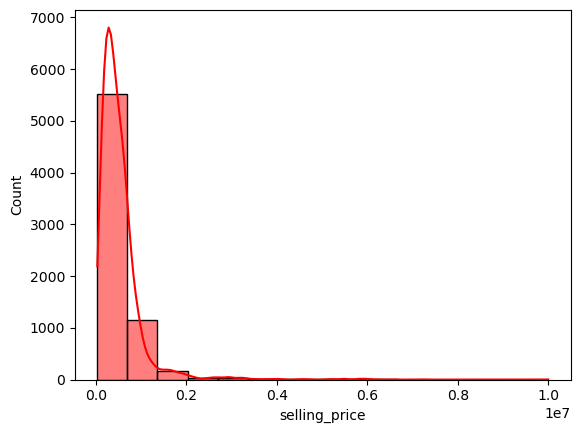

In [49]:
sns.histplot(x="selling_price", data=df, bins=15, color="red", kde=True)

In [51]:
df.selling_price.value_counts().sort_values(ascending=False).head(10)

selling_price
300000    214
350000    201
400000    170
600000    169
250000    167
500000    161
550000    160
450000    148
650000    145
200000    145
Name: count, dtype: int64

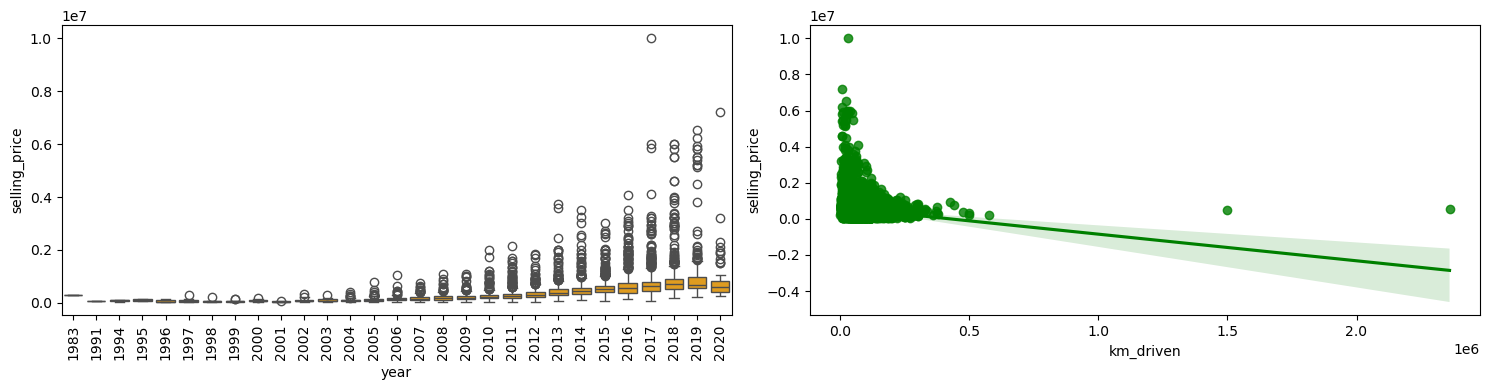

In [58]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(x="year", y="selling_price", data=df, color="orange", ax=ax1)
ax1.tick_params(axis='x', rotation=90)

sns.regplot(x="km_driven", y="selling_price", data=df, color="green", ax=ax2)

plt.tight_layout()
plt.show()

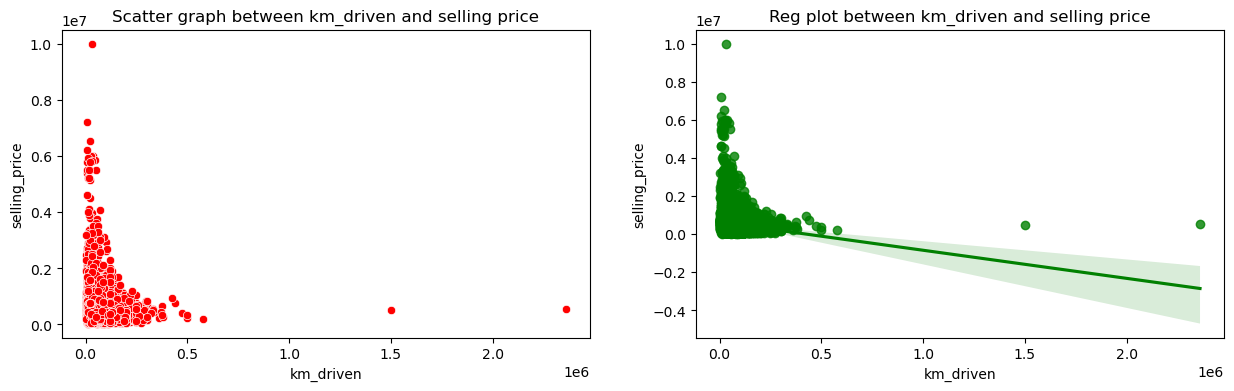

In [59]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

sns.scatterplot(x="km_driven", y="selling_price", data=df, color="red", ax=ax1)
ax1.set_title("Scatter graph between km_driven and selling price")

sns.regplot(x="km_driven", y="selling_price", data=df, color="green", ax=ax2)
ax2.set_title("Reg plot between km_driven and selling price")

plt.show()

In [60]:
df.sample(3)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
2098,Datsun GO T BSIV,2015,225000,71850,Petrol,Individual,Manual,First Owner,20.63,1198.0,67.0,5.0
6419,Tata Indica Vista Terra 1.4 TDI,2009,170000,55768,Diesel,Individual,Manual,First Owner,17.00,1405.0,71.0,5.0
684,Volkswagen Vento Diesel Highline,2011,300000,72000,Diesel,Individual,Manual,Second Owner,20.54,1598.0,103.6,5.0


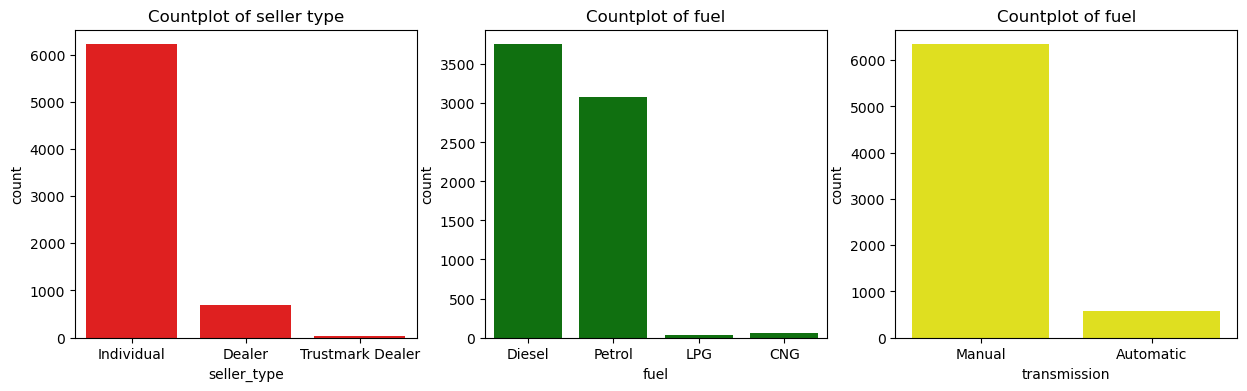

In [77]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x="seller_type", data=df, color="red", ax=ax1)
ax1.set_title("Countplot of seller type")

sns.countplot(x="fuel", data=df, color="green", ax=ax2)
ax2.set_title("Countplot of fuel")

sns.countplot(x="transmission", data=df, color="yellow", ax=ax3)
ax3.set_title("Countplot of fuel")

plt.show()

In [72]:
print(df.seller_type.value_counts(), df.fuel.value_counts())
print(df.shape[])

seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64 fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64
6926


In [74]:
print(df.transmission.value_counts(), df.transmission.value_counts()/df.shape[0])

transmission
Manual       6342
Automatic     584
Name: count, dtype: int64 transmission
Manual       0.91568
Automatic    0.08432
Name: count, dtype: float64


<Axes: xlabel='seats', ylabel='selling_price'>

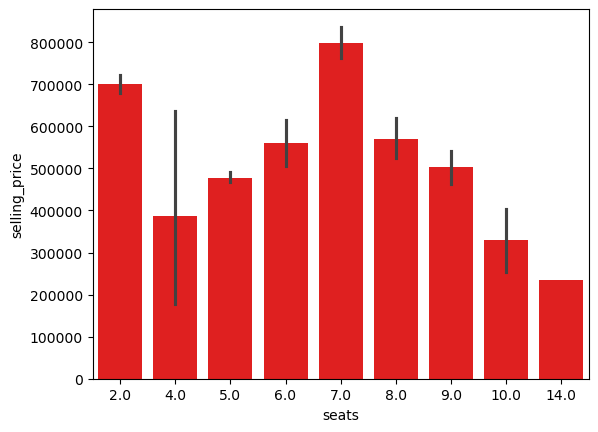

In [84]:
sns.barplot(x="seats", y="selling_price", data=df, color="red")

In [83]:
print(df.seats.value_counts())
print(df.seats.value_counts()/df.shape[0])

seats
5.0     5254
7.0      966
8.0      222
4.0      124
9.0       74
6.0       57
10.0      18
2.0        2
14.0       1
Name: count, dtype: int64
seats
5.0     0.758591
7.0     0.139474
8.0     0.032053
4.0     0.017904
9.0     0.010684
6.0     0.008230
10.0    0.002599
2.0     0.000289
14.0    0.000144
Name: count, dtype: float64


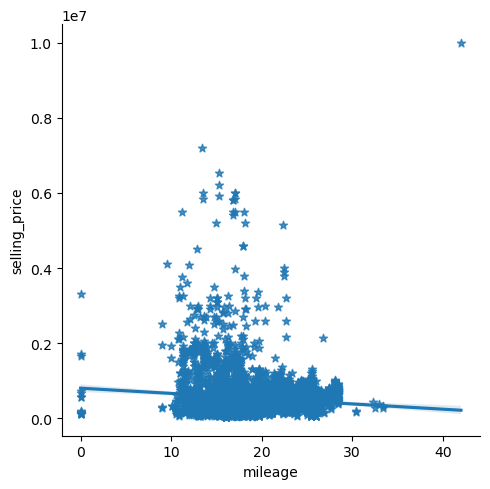

In [91]:
sns.lmplot(x="mileage", y="selling_price", data=df, markers="*")

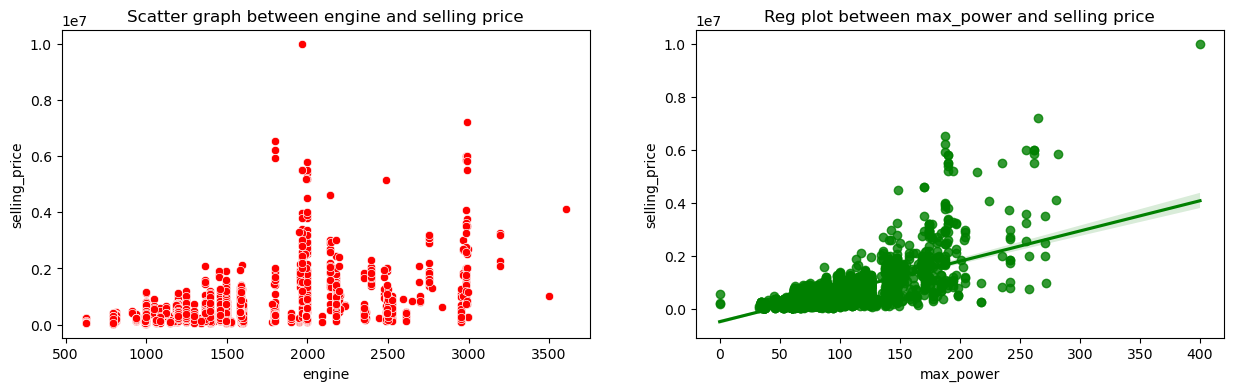

In [92]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

sns.scatterplot(x="engine", y="selling_price", data=df, color="red", ax=ax1)
ax1.set_title("Scatter graph between engine and selling price")

sns.regplot(x="max_power", y="selling_price", data=df, color="green", ax=ax2)
ax2.set_title("Reg plot between max_power and selling price")

plt.show()

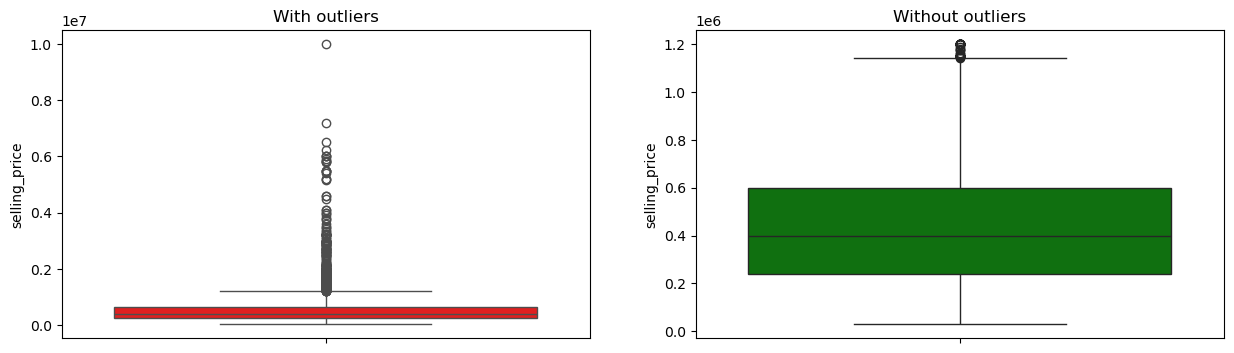

In [94]:
Q1 = df["selling_price"].quantile(0.25)
Q3 = df["selling_price"].quantile(0.75)

IQR = Q3 - Q1

mask = (df["selling_price"] >= Q1-1.5*IQR) & \
        (df["selling_price"] <= Q3+1.5*IQR)

df_clean = df[mask]

##########################################################################

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

sns.boxplot(data=df["selling_price"], color="red", ax=ax1)
ax1.set_title("With outliers")

sns.boxplot(data=df_clean["selling_price"], color="green", ax=ax2)
ax2.set_title("Without outliers")

plt.show()


In [95]:
df['selling_price'].skew()

np.float64(5.572742292649192)

In [96]:
df.describe()

,year,selling_price,km_driven,mileage,engine,max_power,seats
count,6926.000000,6.926000e+03,6.926000e+03,6718.00000,6718.000000,6720.000000,6718.000000
mean,2013.420300,5.172707e+05,7.399568e+04,19.46531,1430.891337,87.726919,5.434653
std,4.078286,5.197670e+05,5.835810e+04,4.04915,493.493277,31.771619,0.984230
min,1983.000000,2.999900e+04,1.000000e+00,0.00000,624.000000,0.000000,2.000000
25%,2011.000000,2.500000e+05,4.000000e+04,16.80000,1197.000000,67.100000,5.000000
50%,2014.000000,4.000000e+05,7.000000e+04,19.44000,1248.000000,81.830000,5.000000
75%,2017.000000,6.335000e+05,1.000000e+05,22.50000,1498.000000,100.000000,5.000000
max,2020.000000,1.000000e+07,2.360457e+06,42.00000,3604.000000,400.000000,14.000000


<Axes: >

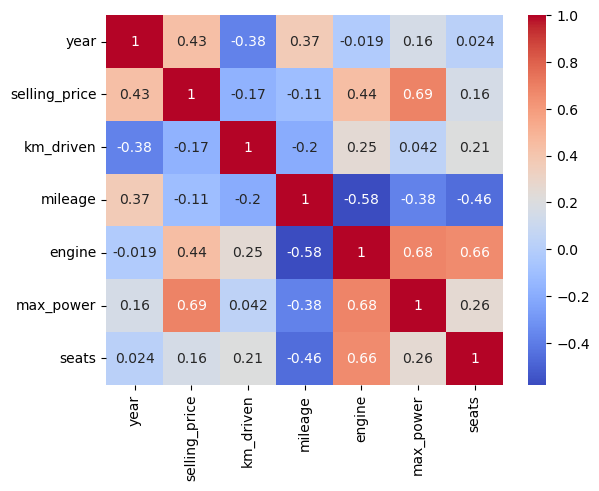

In [102]:
sns.heatmap(df.corr(numeric_only=True), cbar="Reds", cmap="coolwarm", annot=True)

In [104]:
np.log1p(df['selling_price']).skew() 

np.float64(-0.1567962527166043)